In [1]:
# Импорты, seed, устройство и структура папок
import os
import csv
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import copy

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Создаем папки для сохранения результатов
os.makedirs("artifacts/figures", exist_ok=True)

Используемое устройство: cpu


In [2]:
# Данные и DataLoader (Вариант C: CIFAR10)
transform = transforms.Compose([
    transforms.ToTensor(),
    # CIFAR10 - цветные изображения, поэтому 3 канала (RGB)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Разбиение train/val (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(
    train_dataset_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Sanity-check
x_batch, y_batch = next(iter(train_loader))
print(f"Размер батча (X): {x_batch.shape}, (y): {y_batch.shape}")
print(f"Диапазон значений: [{x_batch.min():.4f}, {x_batch.max():.4f}]")

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Размер батча (X): torch.Size([128, 3, 32, 32]), (y): torch.Size([128])
Диапазон значений: [-1.0000, 1.0000]


In [3]:
# Модель MLP и вспомогательные функции для обучения/валидации
class MLP(nn.Module):
    def __init__(self, use_dropout=False, use_bn=False, dropout_p=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        # Скрытый слой 1 (Вход: 32x32 пикселя * 3 канала = 3072)
        layers.append(nn.Linear(32 * 32 * 3, 256))
        if use_bn: layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())
        if use_dropout: layers.append(nn.Dropout(dropout_p))
        
        # Скрытый слой 2
        layers.append(nn.Linear(256, 128))
        if use_bn: layers.append(nn.BatchNorm1d(128))
        layers.append(nn.ReLU())
        if use_dropout: layers.append(nn.Dropout(dropout_p))
        
        # Выходной слой (10 классов)
        layers.append(nn.Linear(128, 10))
        
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(self.flatten(x))

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        
        running_loss += loss.item() * x.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device, patience=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        if patience and epochs_no_improve >= patience:
            print(f"Early stopping сработал на эпохе {epoch+1}")
            break
            
    model.load_state_dict(best_model_wts)
    return history, best_val_acc, best_val_loss

In [4]:
# Настройка структуры для записи метрик в runs.csv
run_logs = []

def log_experiment(exp_id, model_summary, opt_name, lr, momentum, weight_decay, epochs_trained, best_val_acc, best_val_loss):
    run_logs.append({
        'experiment_id': exp_id, 'dataset': 'CIFAR10', 'seed': 42,
        'model_summary': model_summary, 'optimizer': opt_name, 'lr': lr,
        'momentum': momentum, 'weight_decay': weight_decay,
        'epochs_trained': epochs_trained, 'best_val_accuracy': best_val_acc, 'best_val_loss': best_val_loss
    })

EPOCHS_BASE = 10
criterion = nn.CrossEntropyLoss()

--- Запуск E1: Базовая модель ---
Epoch 01/10 | Train Loss: 1.6754 Acc: 0.4033 | Val Loss: 1.5465 Acc: 0.4574
Epoch 02/10 | Train Loss: 1.4553 Acc: 0.4878 | Val Loss: 1.4672 Acc: 0.4811
Epoch 03/10 | Train Loss: 1.3404 Acc: 0.5262 | Val Loss: 1.4182 Acc: 0.5053
Epoch 04/10 | Train Loss: 1.2570 Acc: 0.5566 | Val Loss: 1.4047 Acc: 0.5133
Epoch 05/10 | Train Loss: 1.1730 Acc: 0.5871 | Val Loss: 1.3822 Acc: 0.5254
Epoch 06/10 | Train Loss: 1.1030 Acc: 0.6101 | Val Loss: 1.3835 Acc: 0.5217
Epoch 07/10 | Train Loss: 1.0289 Acc: 0.6391 | Val Loss: 1.3850 Acc: 0.5253
Epoch 08/10 | Train Loss: 0.9711 Acc: 0.6563 | Val Loss: 1.4350 Acc: 0.5237
Epoch 09/10 | Train Loss: 0.9045 Acc: 0.6796 | Val Loss: 1.4631 Acc: 0.5261
Epoch 10/10 | Train Loss: 0.8449 Acc: 0.7011 | Val Loss: 1.4969 Acc: 0.5317

--- Запуск E2: Добавлен Dropout ---
Epoch 01/10 | Train Loss: 1.7924 Acc: 0.3621 | Val Loss: 1.6037 Acc: 0.4392
Epoch 02/10 | Train Loss: 1.6272 Acc: 0.4258 | Val Loss: 1.5313 Acc: 0.4628
Epoch 03/10 | Tra

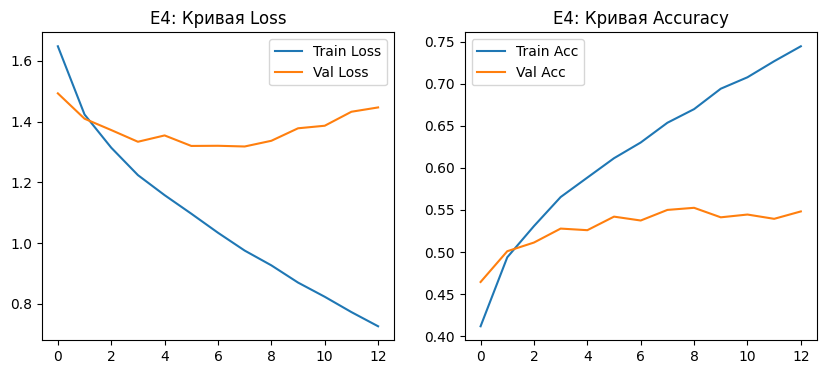


ИТОГОВЫЙ РЕЗУЛЬТАТ НА TEST (E4): Loss=1.3360, Accuracy=0.5381


In [5]:
# Часть A: Регуляризация (E1-E4) и сохранение лучшей модели
print("--- Запуск E1: Базовая модель ---")
model_e1 = MLP().to(device)
opt_e1 = torch.optim.Adam(model_e1.parameters(), lr=1e-3)
hist_e1, val_acc_e1, val_loss_e1 = train_model(model_e1, train_loader, val_loader, criterion, opt_e1, EPOCHS_BASE, device)
log_experiment('E1', '256-128/ReLU/NoReg', 'Adam', 1e-3, 0, 0, EPOCHS_BASE, val_acc_e1, val_loss_e1)

print("\n--- Запуск E2: Добавлен Dropout ---")
model_e2 = MLP(use_dropout=True).to(device)
opt_e2 = torch.optim.Adam(model_e2.parameters(), lr=1e-3)
hist_e2, val_acc_e2, val_loss_e2 = train_model(model_e2, train_loader, val_loader, criterion, opt_e2, EPOCHS_BASE, device)
log_experiment('E2', '256-128/ReLU/Dropout0.3', 'Adam', 1e-3, 0, 0, EPOCHS_BASE, val_acc_e2, val_loss_e2)

print("\n--- Запуск E3: Добавлен BatchNorm ---")
model_e3 = MLP(use_bn=True).to(device)
opt_e3 = torch.optim.Adam(model_e3.parameters(), lr=1e-3)
hist_e3, val_acc_e3, val_loss_e3 = train_model(model_e3, train_loader, val_loader, criterion, opt_e3, EPOCHS_BASE, device)
log_experiment('E3', '256-128/ReLU/BatchNorm', 'Adam', 1e-3, 0, 0, EPOCHS_BASE, val_acc_e3, val_loss_e3)

print("\n--- Запуск E4: Обучение лучшей с EarlyStopping ---")
use_bn_best = val_acc_e3 > val_acc_e2
use_drop_best = not use_bn_best
best_arch_str = 'BatchNorm' if use_bn_best else 'Dropout0.3'

model_e4 = MLP(use_bn=use_bn_best, use_dropout=use_drop_best).to(device)
opt_e4 = torch.optim.Adam(model_e4.parameters(), lr=1e-3)
EPOCHS_ES = 30 
hist_e4, val_acc_e4, val_loss_e4 = train_model(model_e4, train_loader, val_loader, criterion, opt_e4, EPOCHS_ES, device, patience=4)
log_experiment('E4', f'256-128/ReLU/{best_arch_str}/ES', 'Adam', 1e-3, 0, 0, len(hist_e4['train_loss']), val_acc_e4, val_loss_e4)


# Сохранение артефактов E4
torch.save(model_e4.state_dict(), "artifacts/best_model.pt")
best_config = {
    "architecture": "MLP 3072 -> 256 -> 128 -> 10", "use_batchnorm": use_bn_best,
    "use_dropout": use_drop_best, "dataset": "CIFAR10", "seed": 42,
    "optimizer": "Adam", "lr": 1e-3, "early_stopping_patience": 4
}
with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

# Отрисовка графиков для лучшей модели (E4)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_e4['train_loss'], label='Train Loss')
plt.plot(hist_e4['val_loss'], label='Val Loss')
plt.title('E4: Кривая Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_e4['train_acc'], label='Train Acc')
plt.plot(hist_e4['val_acc'], label='Val Acc')
plt.title('E4: Кривая Accuracy')
plt.legend()
plt.savefig('artifacts/figures/curves_best.png')
plt.show()

# Финальное тестирование на Test-сете
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"\nИТОГОВЫЙ РЕЗУЛЬТАТ НА TEST (E4): Loss={test_loss:.4f}, Accuracy={test_acc:.4f}")

--- Запуск O1: Слишком большой Learning Rate ---
Epoch 01/8 | Train Loss: 1.8366 Acc: 0.3402 | Val Loss: 1.7141 Acc: 0.3854
Epoch 02/8 | Train Loss: 1.6502 Acc: 0.4050 | Val Loss: 1.6106 Acc: 0.4213
Epoch 03/8 | Train Loss: 1.5646 Acc: 0.4374 | Val Loss: 1.5467 Acc: 0.4564
Epoch 04/8 | Train Loss: 1.5009 Acc: 0.4634 | Val Loss: 1.5138 Acc: 0.4646
Epoch 05/8 | Train Loss: 1.4616 Acc: 0.4756 | Val Loss: 1.5108 Acc: 0.4666
Epoch 06/8 | Train Loss: 1.4273 Acc: 0.4925 | Val Loss: 1.4896 Acc: 0.4650
Epoch 07/8 | Train Loss: 1.3804 Acc: 0.5071 | Val Loss: 1.4559 Acc: 0.4879
Epoch 08/8 | Train Loss: 1.3493 Acc: 0.5160 | Val Loss: 1.4479 Acc: 0.4922

--- Запуск O2: Слишком маленький Learning Rate ---
Epoch 01/8 | Train Loss: 2.0540 Acc: 0.2664 | Val Loss: 1.9006 Acc: 0.3466
Epoch 02/8 | Train Loss: 1.8413 Acc: 0.3748 | Val Loss: 1.7953 Acc: 0.3946
Epoch 03/8 | Train Loss: 1.7532 Acc: 0.4128 | Val Loss: 1.7319 Acc: 0.4218
Epoch 04/8 | Train Loss: 1.6951 Acc: 0.4350 | Val Loss: 1.6849 Acc: 0.4351

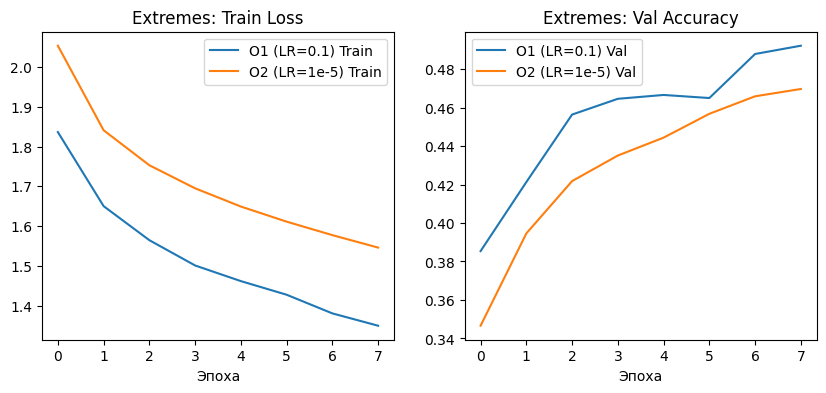

In [6]:
# Часть B: Оптимизация (O1-O3)
EPOCHS_O = 8

print("--- Запуск O1: Слишком большой Learning Rate ---")
model_o1 = MLP(use_bn=use_bn_best, use_dropout=use_drop_best).to(device)
opt_o1 = torch.optim.Adam(model_o1.parameters(), lr=1e-1)
hist_o1, val_acc_o1, val_loss_o1 = train_model(model_o1, train_loader, val_loader, criterion, opt_o1, EPOCHS_O, device)
log_experiment('O1', 'Best_E4_Arch', 'Adam', 1e-1, 0, 0, EPOCHS_O, val_acc_o1, val_loss_o1)

print("\n--- Запуск O2: Слишком маленький Learning Rate ---")
model_o2 = MLP(use_bn=use_bn_best, use_dropout=use_drop_best).to(device)
opt_o2 = torch.optim.Adam(model_o2.parameters(), lr=1e-5)
hist_o2, val_acc_o2, val_loss_o2 = train_model(model_o2, train_loader, val_loader, criterion, opt_o2, EPOCHS_O, device)
log_experiment('O2', 'Best_E4_Arch', 'Adam', 1e-5, 0, 0, EPOCHS_O, val_acc_o2, val_loss_o2)

print("\n--- Запуск O3: SGD + Momentum + Weight Decay ---")
model_o3 = MLP(use_bn=use_bn_best, use_dropout=use_drop_best).to(device)
opt_o3 = torch.optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
hist_o3, val_acc_o3, val_loss_o3 = train_model(model_o3, train_loader, val_loader, criterion, opt_o3, 15, device)
log_experiment('O3', 'Best_E4_Arch', 'SGD', 1e-2, 0.9, 1e-4, 15, val_acc_o3, val_loss_o3)

# Графики экстремальных значений LR
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_o1['train_loss'], label='O1 (LR=0.1) Train')
plt.plot(hist_o2['train_loss'], label='O2 (LR=1e-5) Train')
plt.title('Extremes: Train Loss')
plt.xlabel('Эпоха')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_o1['val_acc'], label='O1 (LR=0.1) Val')
plt.plot(hist_o2['val_acc'], label='O2 (LR=1e-5) Val')
plt.title('Extremes: Val Accuracy')
plt.xlabel('Эпоха')
plt.legend()
plt.savefig('artifacts/figures/curves_lr_extremes.png')
plt.show()

In [7]:
# Сохранение итогового файла runs.csv
csv_file = "artifacts/runs.csv"
keys = run_logs[0].keys()
with open(csv_file, 'w', newline='') as output_file:
    dict_writer = csv.DictWriter(output_file, fieldnames=keys)
    dict_writer.writeheader()
    dict_writer.writerows(run_logs)
    
print("CSV файл успешно сохранен! Можно переносить метрики в report.md")

CSV файл успешно сохранен! Можно переносить метрики в report.md
